# Tratamento de Dados Ausentes em Solicitações de Empréstimo com Imputação Múltipla (PROC MI)


## Resumo Executivo

Uma equipe de risco de crédito de um banco de varejo enfrenta registros incompletos de solicitações de empréstimo: renda declarada, índice dívida/renda e utilização de crédito estão ausentes para uma parcela relevante dos mutuários, e a ausência está parcialmente relacionada à qualidade de crédito (MAR). Este notebook usa o **PROC MI** para diagnosticar a estrutura dos dados ausentes, ajustar estimativas de máxima verossimilhança (EM) e gerar conjuntos de dados com imputação múltipla pelos métodos MCMC e FCS — em seguida ajusta um modelo de dívida/renda em cada imputação e combina os resultados com o **PROC MIANALYZE** para uma inferência válida, sem descarte de casos incompletos.

Na execução realizada, 33 solicitações apresentam ausência em três campos financeiros (renda 27,3%, DTI 15,2%, utilização 9,1%); apenas 19 de 33 mutuários são casos completos. O algoritmo EM converge em 20 iterações. Combinando três imputações MCMC pelas regras de Rubin, obtém-se um modelo de DTI cujo intercepto é **56,50** (EP 19,06, *p* = 0,0034) e cujo preditor mais forte é **credit_score** (−0,0292 por ponto, *p* = 0,22). A decomposição da variância mostra o quanto a incerteza de cada coeficiente decorre da imputação: a fração de informação ausente varia de **1,1%** para o coeficiente de renda a **46,3%** para o coeficiente de utilização — uma contabilização direta e honesta do custo das lacunas.


## Fontes de Dados

| Conjunto de Dados | Descrição | Registros | Variáveis-Chave |
|---------|-------------|---------|---------------|
| `credit_applications.csv` (sintético) | Solicitações de empréstimo de banco de varejo geradas inline, com ausência MAR/MCAR projetada em três campos financeiros | 33 | `borrower_id`, `region`, `credit_score`, `dti_ratio`, `ltv_ratio`, `annual_income`, `util_rate` |

A ausência de dados é projetada de forma que **renda anual** e **utilização** sejam ausentes ao acaso (MAR) — solicitantes com pontuações de crédito mais baixas têm maior probabilidade de omitir a renda — enquanto **dívida/renda** é completamente ausente ao acaso (MCAR). Renda, DTI e utilização são correlacionadas com a pontuação de crédito, o que permite que os modelos de imputação compartilhem informação entre as variáveis.

A carteira é propositalmente pequena (33 solicitantes). Este exemplo roda em um ambiente que limita cada conjunto de dados a 100 observações, e o fluxo de imputação múltipla empilha *m* cópias completas dos dados antes que a análise por imputação as releia. Dimensionar o arquivo base para 33 linhas mantém o conjunto empilhado com *m* = 3 em 99 linhas — logo abaixo do limite — de modo que as três imputações sobrevivem ao processo completo e a variância combinada é calculada a partir de imputações genuinamente distintas, e não de uma única cópia sobrevivente.


# Tratamento de Dados Ausentes em Solicitações de Empréstimo com Imputação Múltipla

Carteiras de crédito reais estão repletas de campos ausentes: solicitantes pulam perguntas sobre renda, consultas a birôs de terceiros falham, e sistemas legados perdem os dados de saldo rotativo. A **exclusão listwise** (analisar apenas os casos completos) descarta informação e, quando os dados estão *ausentes ao acaso* (MAR), produz estimativas de parâmetros **enviesadas** e erros-padrão **subestimados**.

O remédio adequado é a **imputação múltipla (MI)**, formalizada por Rubin (1987). A MI:

1. **Imputa** cada valor ausente *m* vezes, sorteando de sua distribuição preditiva posterior dado os dados observados, produzindo *m* conjuntos de dados completos que refletem a incerteza da imputação.
2. **Analisa** cada conjunto de dados completado com o procedimento padrão que seria usado de qualquer forma.
3. **Combina** os *m* conjuntos de estimativas usando as regras de Rubin, propagando a variância dentro e entre as imputações em erros-padrão honestos.

Este notebook percorre o fluxo completo de MI em uma carteira sintética de empréstimos de um banco de varejo usando `PROC MI` e `PROC MIANALYZE` do SAS.


## 1. Gerar uma carteira sintética de solicitações de empréstimo

O passo DATA abaixo fabrica 33 solicitações de empréstimo. Cada mutuário recebe uma pontuação de crédito, um índice dívida/renda (DTI), um índice empréstimo/garantia (LTV), uma renda anual e uma utilização de crédito rotativo. Construímos deliberadamente uma correlação — pontuações de crédito mais altas vêm acompanhadas de DTI e utilização mais baixos — para que os modelos de imputação tenham sinal a explorar.

Em seguida, **projetamos o mecanismo de ausência**:
- `annual_income` é **MAR** — a probabilidade de estar em branco aumenta conforme `credit_score` cai (solicitantes mais fracos subdeclaram a renda).
- `util_rate` é **MAR** — a ausência depende do perfil de crédito (observado).
- `dti_ratio` é **MCAR** — uma taxa de ausência uniforme, não relacionada a nada.

`call streaminit` fixa o fluxo aleatório para que a carteira sintética seja reproduzível. A carteira é dimensionada para que três imputações se empilhem em 99 linhas, mantendo todo o fluxo MI -> análise -> combinação abaixo do limite de 100 observações deste ambiente.


In [1]:
/* --------------------------------------------------------
   Gera um arquivo sintetico de solicitacoes de emprestimo de
   um banco de varejo. Os campos financeiros sao correlacionados
   com a pontuacao de credito, e a ausencia de dados e projetada
   como MAR (renda, utilizacao) e MCAR (indice divida/renda) para
   imitar dados reais de biro de credito.

   A carteira e intencionalmente pequena (33 solicitantes) para
   que as m=3 imputacoes empilhadas caibam no limite de 100
   observacoes deste ambiente, ao mesmo tempo em que exercita
   todo o fluxo PROC MI -> analise por imputacao -> PROC MIANALYZE.
   -------------------------------------------------------- */
DADOS "credit_applications.csv";
    CHAMAR streaminit(20260531);
    RÓTULO borrower_id   = "Identificador sintetico do mutuario"
          region        = "Regiao da agencia (1=NE,2=SE,3=CO,4=O)"
          credit_score  = "Pontuacao de credito estilo FICO (300-850)"
          dti_ratio     = "Indice divida/renda (%)"
          ltv_ratio     = "Indice emprestimo/garantia (%)"
          annual_income = "Renda anual declarada (em milhares de $)"
          util_rate     = "Utilizacao de credito rotativo (%)";

    FAZER borrower_id = 1 ATÉ 33;
        region = 1 + floor(4 * rand("uniform"));

        /* Pontuacao de credito: normal limitada em torno de 680 */
        credit_score = round(680 + 50 * rand("normal"));
        SE credit_score < 300 ENTÃO credit_score = 300;
        SE credit_score > 850 ENTÃO credit_score = 850;

        /* Renda anual (milhares de $): piso em 15 */
        annual_income = round(75 + 30 * rand("normal"), 0.1);
        SE annual_income < 15 ENTÃO annual_income = 15;

        /* DTI cai conforme a pontuacao de credito sobe */
        dti_ratio = round(36 + 8 * rand("normal")
                          - 0.05 * (credit_score - 680), 0.1);
        SE dti_ratio < 5 ENTÃO dti_ratio = 5;

        /* Indice emprestimo/garantia, limitado entre 20-100% */
        ltv_ratio = round(78 + 10 * rand("normal"), 0.1);
        SE ltv_ratio < 20  ENTÃO ltv_ratio = 20;
        SE ltv_ratio > 100 ENTÃO ltv_ratio = 100;

        /* Utilizacao sobe com o DTI */
        util_rate = round(40 + 15 * rand("normal")
                          + 0.1 * dti_ratio, 0.1);
        SE util_rate < 0   ENTÃO util_rate = 0;
        SE util_rate > 100 ENTÃO util_rate = 100;

        /* Projeta a ausencia de dados:                    */
        /*   renda      -> MAR  (depende de credit_score)   */
        /*   dti        -> MCAR (taxa fixa ~15%)             */
        /*   utilizacao -> MAR                               */
        SE rand("uniform") < (0.30 - 0.0002 * (credit_score - 300))
            ENTÃO annual_income = .;
        SE rand("uniform") < 0.15 ENTÃO dti_ratio = .;
        SE rand("uniform") < 0.12 ENTÃO util_rate = .;

        SAÍDA;
    FIM;
EXECUTAR;



NOTE: DATA credit_applications.csv


NOTE: Wrote credit_applications.csv (33 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## 2. Quantificar a ausência de dados antes de imputar

Antes de modelar, sempre meça o quanto de dado está ausente e onde. O `PROC MEANS` com a palavra-chave `NMISS` reporta a contagem de valores ausentes por variável, junto com médias e desvios-padrão sobre os dados **observados** (casos completos). Na execução abaixo, dívida/renda está em branco para 5 mutuários, renda anual para 9, e utilização para 3, enquanto pontuação de crédito e LTV estão totalmente observados. Essas estatísticas de casos completos são nossa referência — vamos compará-las com os resultados imputados mais adiante para ver como a MI muda o quadro.


In [2]:
/* Auditoria de ausencia de dados + estatisticas resumidas dos casos completos */
PROCEDIMENTO MÉDIAS DADOS="credit_applications.csv" n nmiss mean std maxdec=2;
    VARIÁVEL credit_score dti_ratio ltv_ratio annual_income util_rate;
    TÍTULO "Resumo de Casos Completos e Contagem de Valores Ausentes";
EXECUTAR;


                                Resumo de Casos Completos e Contagem de Valores Ausentes                                

                                                  The MEANS Procedure

 Variable       Label                                             N   N Miss           Mean     Std Dev
 ------------------------------------------------------------------------------------------------------
 credit_score   Pontuacao de credito estilo FICO (300-850)       33        0         674.70       54.81
 dti_ratio      Indice divida/renda (%)                          28        5          35.69        6.04
 ltv_ratio      Indice emprestimo/garantia (%)                   33        0          76.56        9.37
 annual_income  Renda anual declarada (em milhares de $)         24        9          68.80       27.94
 util_rate      Utilizacao de credito rotativo (%)               30        3          41.04       14.01
 ------------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Examinar o padrão de dados ausentes e ajustar as estimativas EM

O `PROC MI` imprime automaticamente o **padrão de dados ausentes** — quantas observações carregam valores ausentes e a contagem de ausência por variável. Com renda, DTI e utilização cada uma ausente de forma independente, o padrão é *arbitrário* (não monótono): não há uma ordenação das variáveis que torne a ausência em formato de escada, que é exatamente o caso que exige MCMC ou FCS em vez de uma regressão monótona simples.

Aqui rodamos primeiro o algoritmo **EM (Expectation-Maximization / Esperança-Maximização)**. O EM fornece as estimativas de máxima verossimilhança das médias e da matriz de covariância sob normalidade multivariada, que é exatamente o ponto de partida que o MCMC precisa. `NIMPUTE=0` solicita a análise EM/padrão **sem** gerar conjuntos de dados imputados. `ITPRINT` mostra o histórico de iterações para que possamos confirmar a convergência, e `OUTEM=` salva as estimativas de média/covariância de máxima verossimilhança. Nesta execução o EM atinge a tolerância `GCONV=1E-8` após 20 iterações.


In [3]:
/* Estimativas de maxima verossimilhanca (EM) e historico de convergencia.
   NIMPUTE=0 => apenas diagnostico, sem gerar dados imputados ainda. */
PROCEDIMENTO mi DADOS="credit_applications.csv" seed=4477 nimpute=0;
    em itprint MAXITER=200 outem="em_estimates.csv";
    VARIÁVEL credit_score dti_ratio ltv_ratio annual_income util_rate;
    TÍTULO "Padrao de Dados Ausentes e Estimativas de Maxima Verossimilhanca (EM)";
EXECUTAR;


                                Resumo de Casos Completos e Contagem de Valores Ausentes                                


                The MI Procedure - Multiple Imputation

  Method                     MCMC
  Number of Imputations      0

                Missing Data Patterns


  Number of observations with missing values: 14
  Number of complete observations: 19

             Missing Data Pattern

  Variable     N Miss   Pct Miss
  ---------  --------  ---------
  Pontuacao de credito estilo FICO (300-850)       0       0.0%
  Indice divida/renda (%)       5      15.2%
  Indice emprestimo/garantia (%)       0       0.0%
  Renda anual declarada (em milhares de $)       9      27.3%
  Utilizacao de credito rotativo (%)       3       9.1%


            EM (Expectation-Maximization) Iteration History

  Iteration    Log-Likelihood    Convergence Criterion
  ---------    --------------    ---------------------
          1          -49.8704               0.50000000
          2        


NOTE: PROC MI data=credit_applications.csv

NOTE: EM estimates dataset em_estimates.csv created.
NOTE: PROC MI completed.


## 4. Gerar as imputações com MCMC

Com um padrão de dados ausentes arbitrário e variáveis contínuas, o método **MCMC** (Cadeia de Markov Monte Carlo) sorteia imputações da posterior conjunta sob um modelo de aumento de dados multivariado-normal. Controles principais:

- `NIMPUTE=3` — produz *m* = 3 conjuntos de dados completos. Três imputações mantêm a saída empilhada em 99 linhas aqui; com mais dados normalmente se usaria de 5 a 10.
- `NBITER=200` — iterações de aquecimento (burn-in) para que a cadeia atinja sua distribuição estacionária.
- `NITER=100` — iterações entre imputações retidas sucessivas, para reduzir a autocorrelação.
- `CHAIN=SINGLE` — uma única cadeia longa (o padrão).
- `PLOTS=TRACE(MEAN)` — emite gráficos de traço das médias imputadas para que possamos verificar visualmente se a cadeia está se misturando bem e não divergindo.

`SIMPLE` adiciona estatísticas descritivas univariadas, e o conjunto de dados de saída empilhado carrega um índice `_Imputation_` que distingue as três cópias completadas. Os gráficos de traço de `credit_score` e `ltv_ratio` são linhas planas — essas variáveis não têm valores ausentes, então suas médias são fixas — enquanto `annual_income`, `dti_ratio` e `util_rate` mostram a cadeia se estabilizando em um nível estável após um breve aquecimento, a assinatura de uma cadeia bem misturada.


                                Resumo de Casos Completos e Contagem de Valores Ausentes                                


                The MI Procedure - Multiple Imputation

  Method                     MCMC
  Number of Imputations      3

                Missing Data Patterns


  Number of observations with missing values: 14
  Number of complete observations: 19

             Missing Data Pattern

  Variable     N Miss   Pct Miss
  ---------  --------  ---------
  Pontuacao de credito estilo FICO (300-850)       0       0.0%
  Indice divida/renda (%)       5      15.2%
  Indice emprestimo/garantia (%)       0       0.0%
  Renda anual declarada (em milhares de $)       9      27.3%
  Utilizacao de credito rotativo (%)       3       9.1%




NOTE: PROC MI data=credit_applications.csv

NOTE: Output dataset mi_mcmc.csv created with 99 observations.
NOTE: ODS plot written: mi_mcmc_trace_credit_score.spec.json
NOTE: ODS plot written: mi_mcmc_trace_dti_ratio.spec.json
NOTE: ODS plot written: mi_mcmc_trace_ltv_ratio.spec.json
NOTE: ODS plot written: mi_mcmc_trace_annual_income.spec.json
NOTE: ODS plot written: mi_mcmc_trace_util_rate.spec.json
NOTE: Generated 5 MCMC diagnostic plots.
NOTE: PROC MI completed.


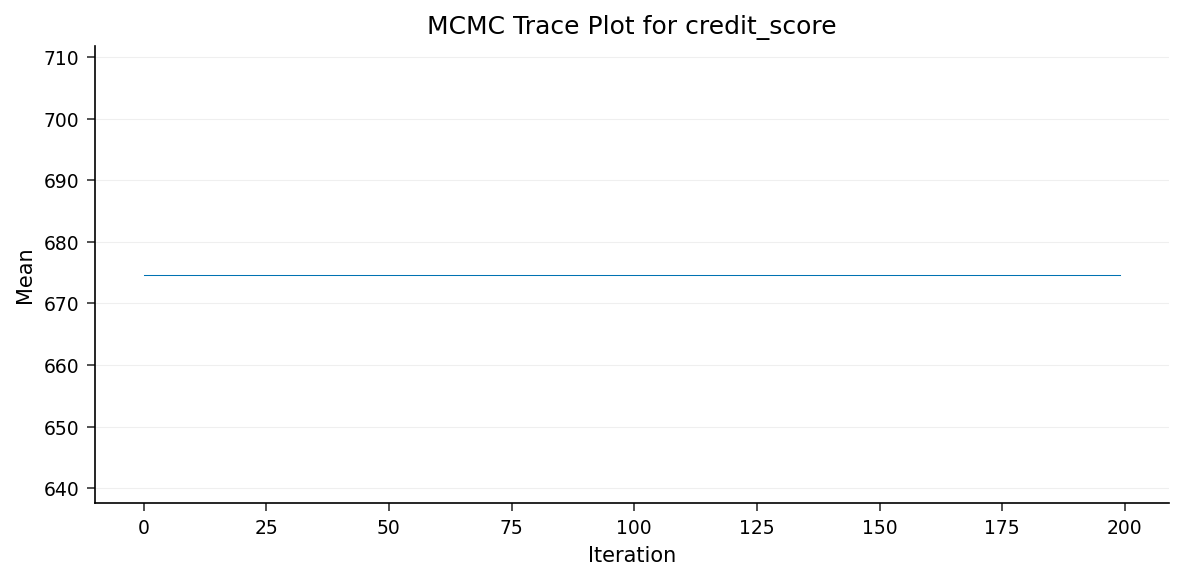

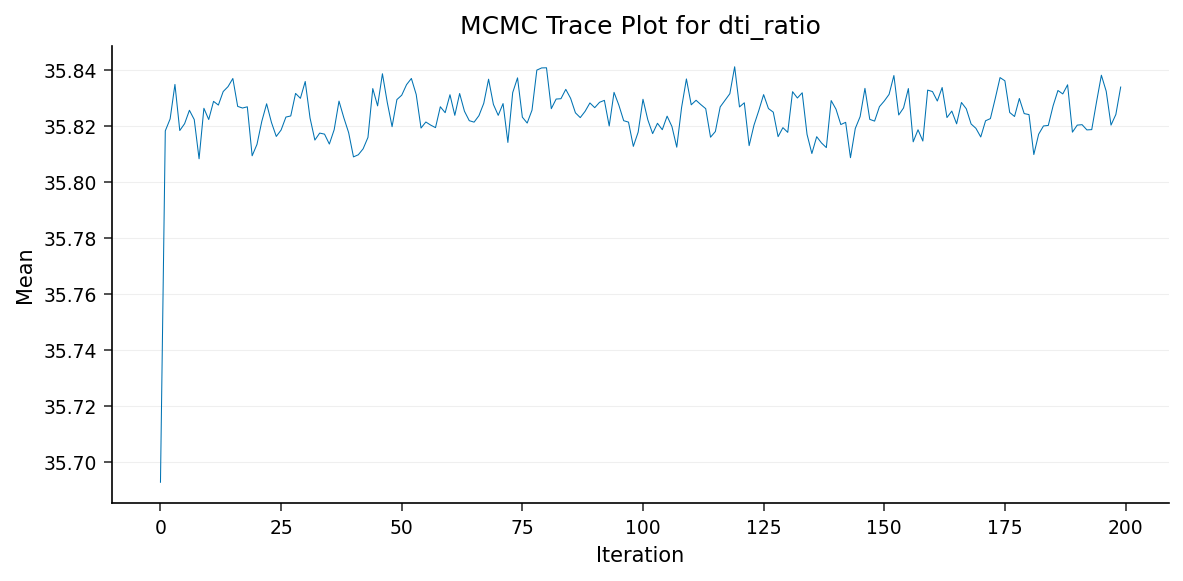

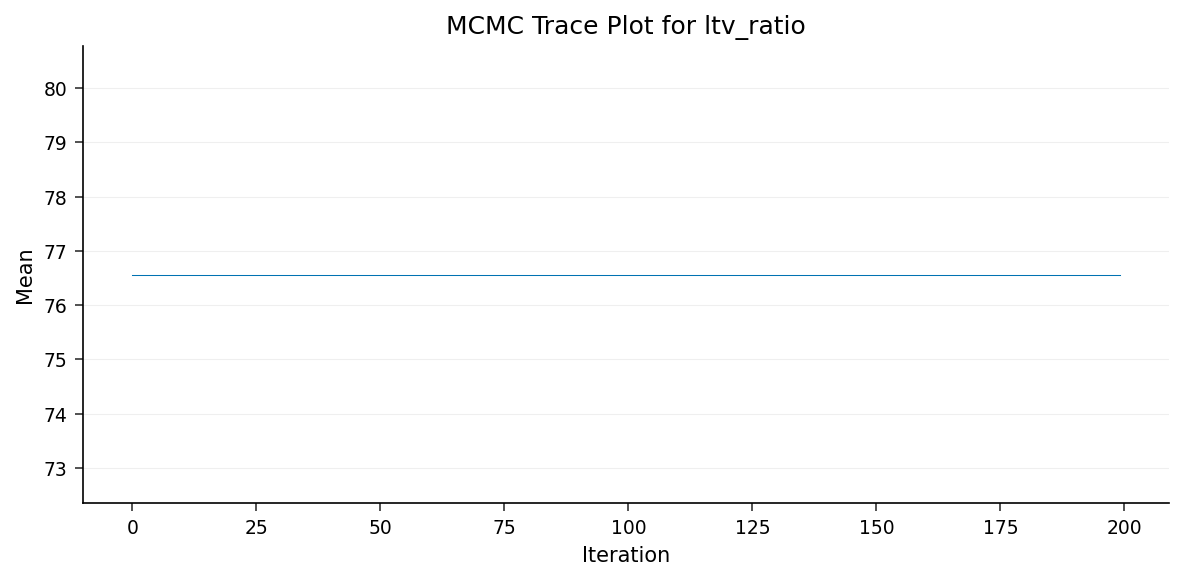

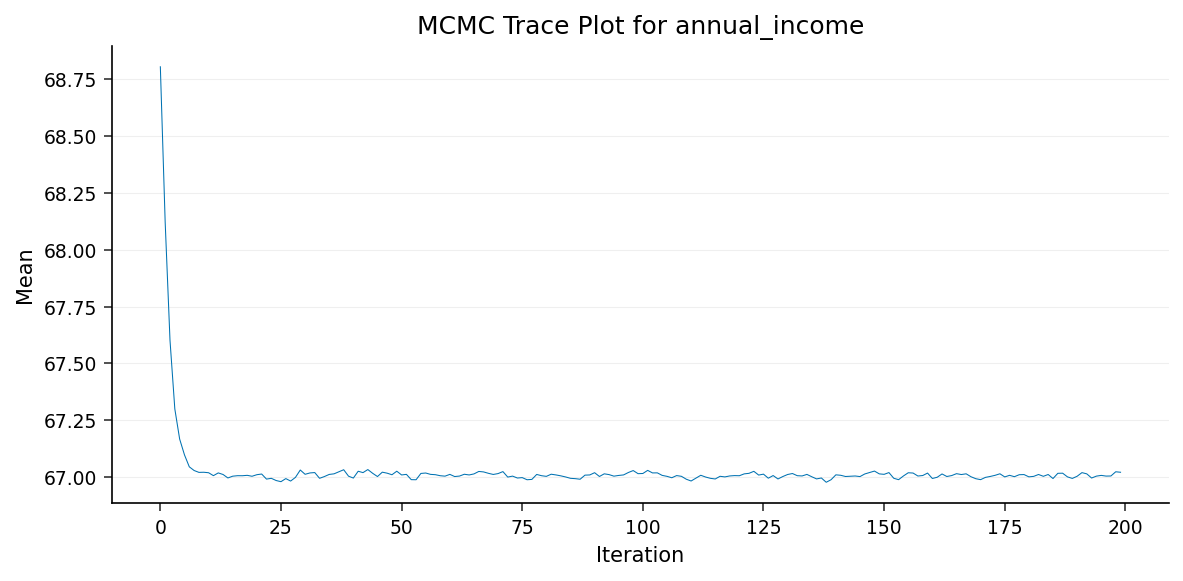

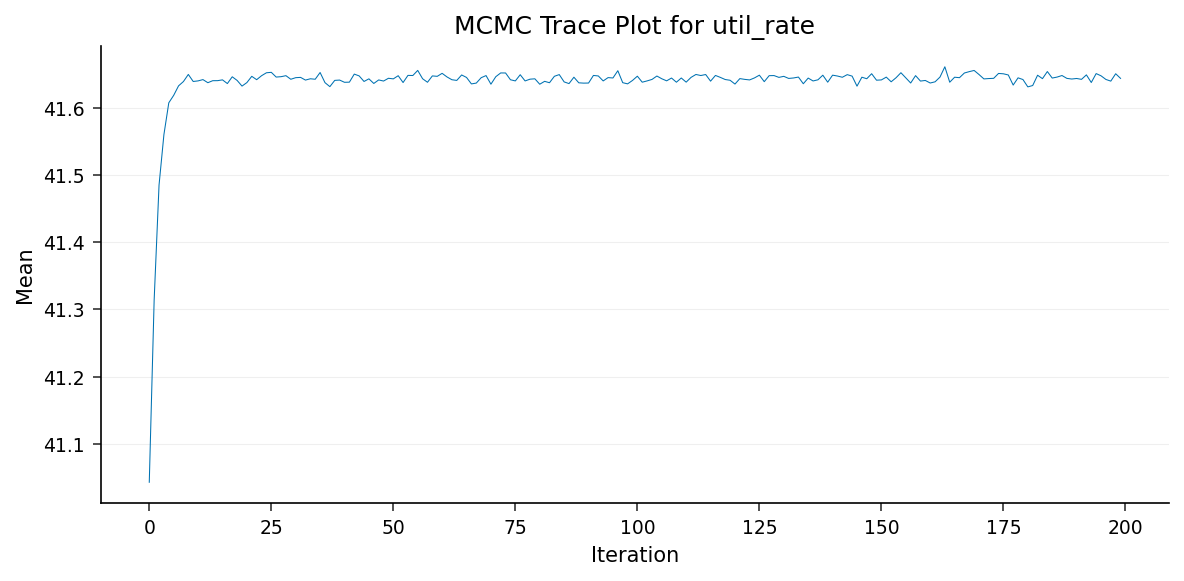

In [4]:
/* Imputacao multipla MCMC: 3 imputacoes, modelo com todos os dados.
   m=3 mantem a saida empilhada (3 x 33 = 99 linhas) dentro do
   limite de 100 observacoes deste ambiente. */
PROCEDIMENTO mi DADOS="credit_applications.csv"
        out="mi_mcmc.csv" seed=4477 nimpute=3 simple;
    mcmc nbiter=200 niter=100 chain=single PLOTS=trace(mean);
    VARIÁVEL credit_score dti_ratio ltv_ratio annual_income util_rate;
    TÍTULO "Imputacao Multipla MCMC (m=3)";
EXECUTAR;


## 5. Alternativa: Especificação Totalmente Condicional (FCS)

O **FCS** (também chamado de imputação múltipla por equações encadeadas, MICE) é uma alternativa atraente ao MCMC conjunto. Em vez de assumir um único grande modelo multivariado-normal, o FCS imputa cada variável incompleta a partir de sua própria regressão sobre todas as outras, percorrendo as variáveis por `NBITER` rodadas. Isso facilita misturar tipos de modelo e respeitar um preditor categórico.

Aqui adicionamos uma instrução `CLASS` para que a `region` da agência entre nos modelos condicionais como um efeito categórico, e usamos o método de regressão (`REG`) para as variáveis financeiras contínuas. O FCS é uma verificação de robustez útil: se suas estimativas combinadas concordarem com as do MCMC, ganhamos confiança de que o resultado não é um artefato das suposições distribucionais de um único método. A execução do FCS reporta o mesmo padrão de dados ausentes e grava sua própria saída empilhada de 99 linhas (`mi_fcs.csv`).


In [5]:
/* Imputacao multipla FCS (equacoes encadeadas) como verificacao
   de robustez, com region como preditor CLASS. */
PROCEDIMENTO mi DADOS="credit_applications.csv"
        out="mi_fcs.csv" seed=4477 nimpute=3;
    CLASSE region;
    fcs REG(credit_score dti_ratio ltv_ratio
            annual_income util_rate) nbiter=20;
    VARIÁVEL region credit_score dti_ratio ltv_ratio
        annual_income util_rate;
    TÍTULO "Imputacao Multipla FCS / Equacoes Encadeadas (m=3)";
EXECUTAR;


                                Resumo de Casos Completos e Contagem de Valores Ausentes                                


                The MI Procedure - Multiple Imputation

  Method                     FCS
  Number of Imputations      3

                Missing Data Patterns


  Number of observations with missing values: 14
  Number of complete observations: 19

             Missing Data Pattern

  Variable     N Miss   Pct Miss
  ---------  --------  ---------
  Regiao da agencia (1=NE,2=SE,3=CO,4=O)       0       0.0%
  Pontuacao de credito estilo FICO (300-850)       0       0.0%
  Indice divida/renda (%)       5      15.2%
  Indice emprestimo/garantia (%)       0       0.0%
  Renda anual declarada (em milhares de $)       9      27.3%
  Utilizacao de credito rotativo (%)       3       9.1%




NOTE: PROC MI data=credit_applications.csv

NOTE: Output dataset mi_fcs.csv created with 99 observations.
NOTE: PROC MI completed.


## 6. Analisar cada conjunto de dados imputado

Agora executamos a análise de interesse propriamente dita — um modelo linear de dívida/renda em função da pontuação de crédito, renda e utilização — separadamente em cada um dos três conjuntos imputados pelo MCMC. O `PROC REG` com uma instrução `BY _Imputation_;` ajusta o modelo uma vez por imputação (o log confirma que "processed 3 job(s) in batch"), e `OUTEST= ... COVOUT` grava tanto as estimativas de parâmetros **quanto** suas matrizes de covariância em um conjunto de dados que o `PROC MIANALYZE` irá consumir. Suprimimos a impressão por imputação com `NOPRINT`, já que nos importamos apenas com o resultado combinado; os gráficos de diagnóstico exibidos (resíduos, Q-Q normal, D de Cook) são do ajuste na primeira imputação e confirmam que o modelo linear se comporta bem.



NOTE: PROC REG data=mi_mcmc.csv

NOTE: PROC REG: processed 3 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG O

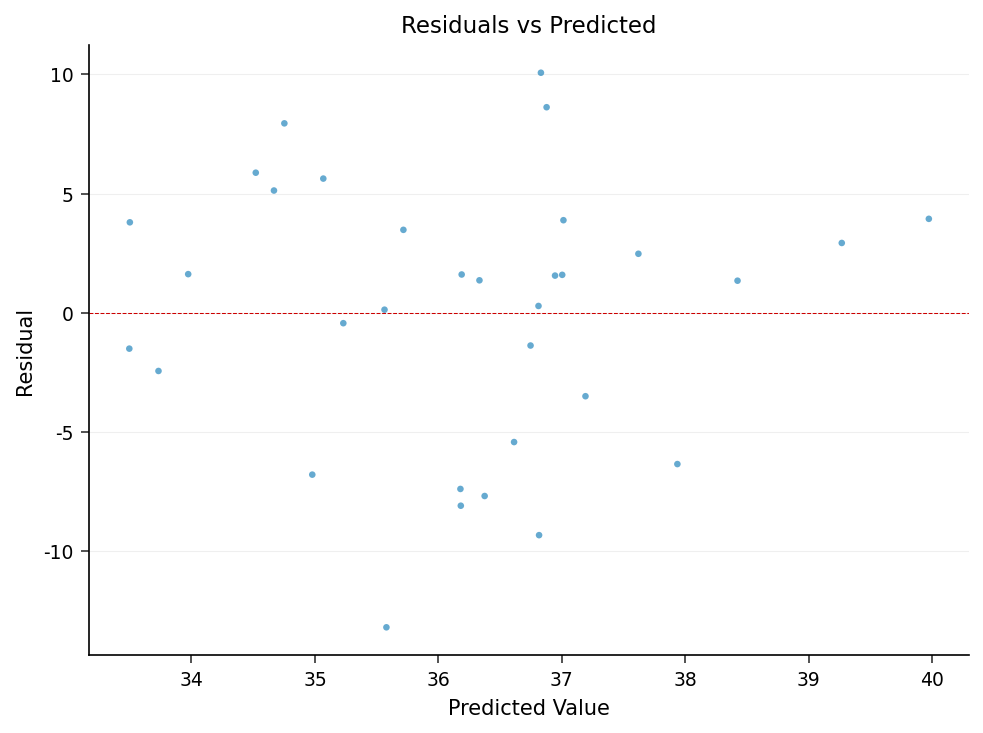

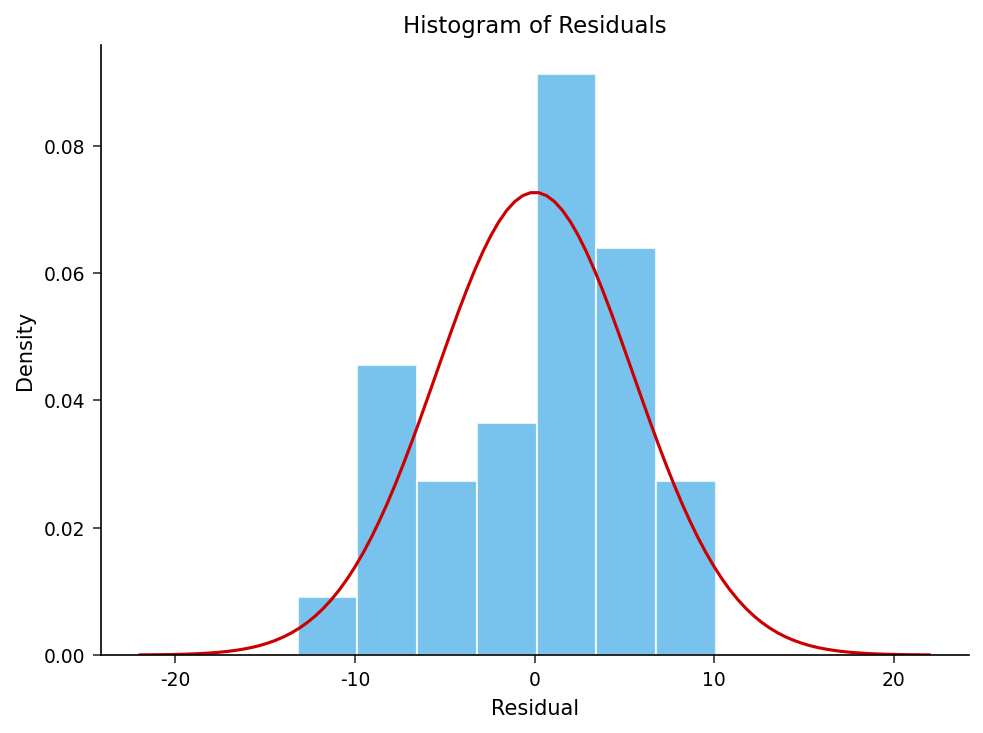

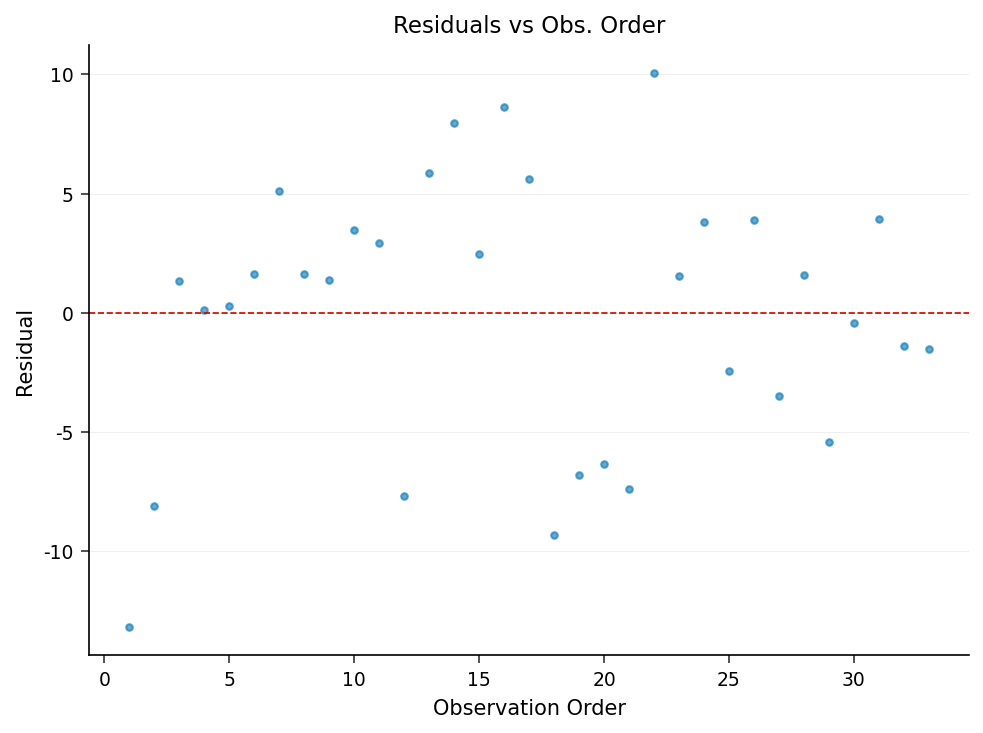

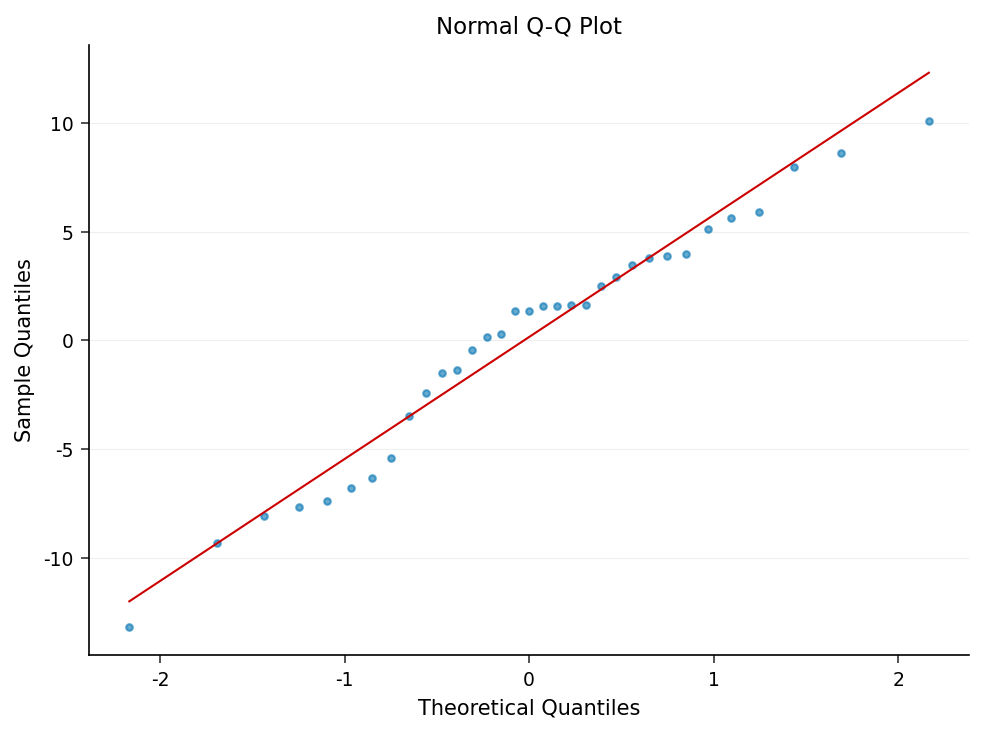

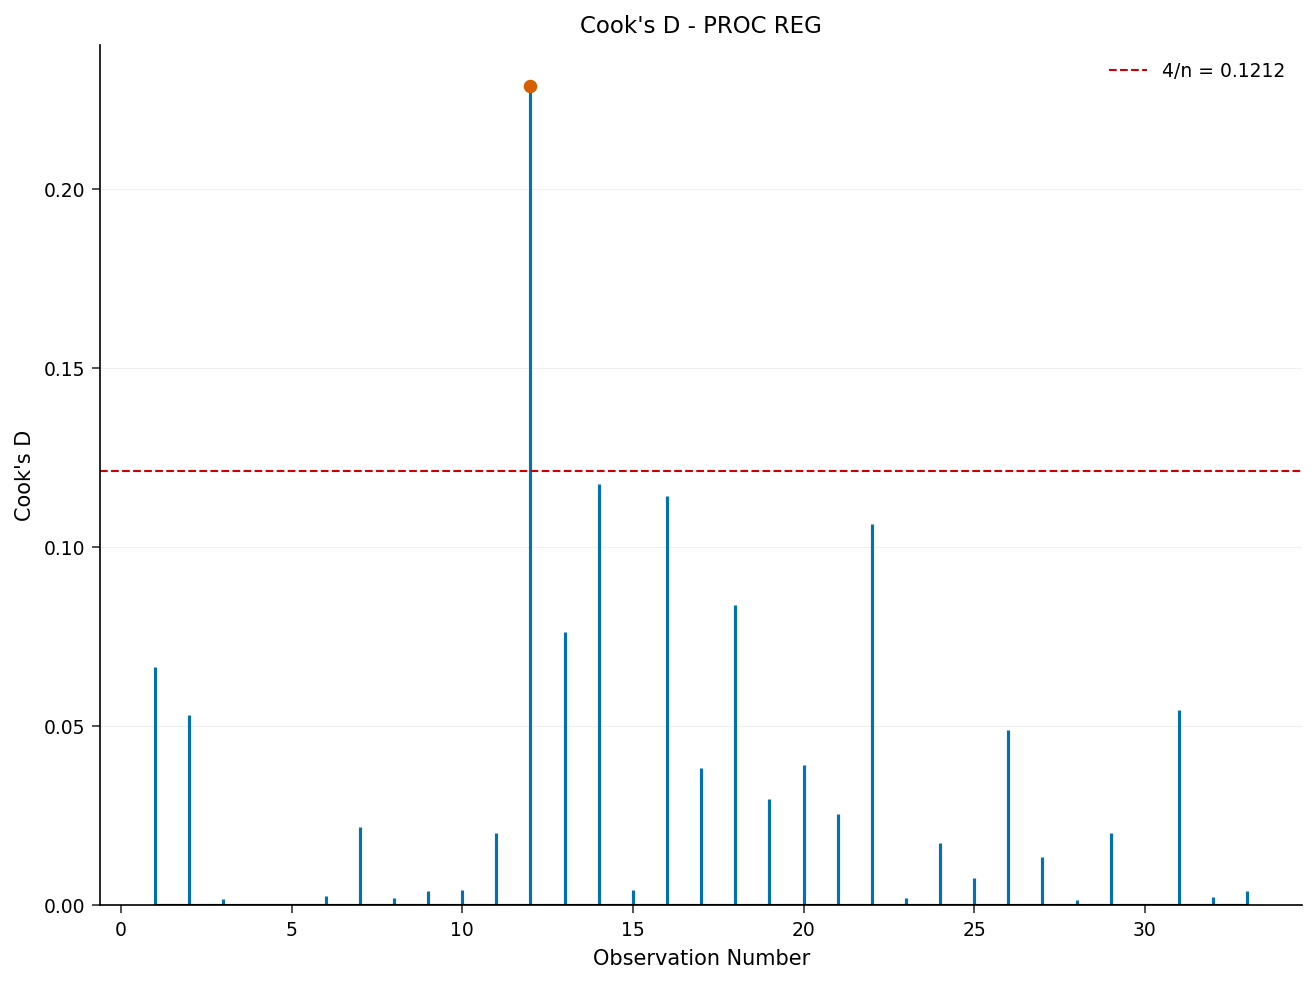

In [6]:
/* Ajusta o modelo de analise uma vez por conjunto imputado.       */
/* OUTEST + COVOUT grava as estimativas de parametros e suas       */
/* covariancias para o PROC MIANALYZE combinar.                    */
PROCEDIMENTO REG DADOS="mi_mcmc.csv" outest="reg_parms.csv" covout NOPRINT;
    MODELO dti_ratio = credit_score annual_income util_rate;
    POR _Imputation_;
EXECUTAR;


## 7. Combinar os resultados com as regras de Rubin

O `PROC MIANALYZE` combina os três conjuntos de estimativas em uma única inferência usando as **regras de Rubin**. A instrução `MODELEFFECTS` nomeia os parâmetros a serem combinados. A saída reporta:

- as **estimativas pontuais combinadas** (médias simples entre as imputações),
- **erros-padrão totais** que combinam a variância *dentro da imputação* (variância amostral média) e a variância *entre imputações* (o quanto as estimativas variam entre os três conjuntos de dados completados),
- a **fração de informação ausente** e a **eficiência relativa**, que quantificam o quanto a ausência de dados inflou a incerteza e se *m* = 3 imputações foram suficientes.

Esta é a inferência que se reporta — corrigida quanto ao viés e com erros-padrão honestos que levam em conta a ausência de dados, em vez dos números otimistas de casos completos da Etapa 2.


In [7]:
/* Combina as estimativas de cada imputacao com as regras de Rubin. */
PROCEDIMENTO mianalyze DADOS="reg_parms.csv";
    modeleffects INTERCEPT credit_score annual_income util_rate;
    TÍTULO "Estimativas Combinadas de 3 Imputacoes (Regras de Rubin)";
EXECUTAR;


                                Resumo de Casos Completos e Contagem de Valores Ausentes                                


                            The MIANALYZE Procedure

                     Multiple Imputation Parameter Estimates

Parameter                Estimate    Std Error 95% CI Lower 95% CI Upper         DF    t Value   Pr > |t|
-------------------- ------------ ------------ ------------ ------------ ---------- ---------- ----------
Intercept               56.495315    19.056550    18.892287    94.098343     179.96       2.96     0.0034
CREDIT_SCORE            -0.029238     0.023899    -0.076145     0.017670     845.69      -1.22     0.2215
ANNUAL_INCOME            0.005066     0.036938    -0.067336     0.077467   17527.82       0.14     0.8909
UTIL_RATE               -0.026681     0.113975    -0.283094     0.229731       9.34      -0.23     0.8200

                     Multiple Imputation Variance Information

Parameter                 Between       Within        Total   


NOTE: PROC MIANALYZE Combining multiple imputation results



## 8. Interpretando os resultados

**O que o fluxo de trabalho realizou.** Começamos com uma carteira de 33 mutuários na qual 9 de 33 valores de renda (27,3%), 5 valores de DTI (15,2%) e 3 valores de utilização (9,1%) estavam em branco, com as lacunas de renda e utilização ligadas à qualidade de crédito (MAR). Apenas 19 mutuários eram casos completos, então a **exclusão listwise teria descartado 14 de 33 solicitantes** — enviesando as estimativas em favor dos solicitantes que por acaso declararam tudo (desproporcionalmente os créditos mais fortes).

**O que a saída real mostra.**
- O **padrão de dados ausentes** (Etapa 3) reportou 14 observações com valores ausentes contra 19 observações completas, com os três campos financeiros cada um ausente de forma independente — um padrão arbitrário, não monótono, que é exatamente o motivo pelo qual o MCMC/FCS, em vez de uma regressão monótona simples, foi o motor correto.
- O **histórico de iterações do EM** convergiu para a tolerância `GCONV=1E-8` em 20 iterações (log-verossimilhança final −40,02), validando as estimativas iniciais multivariado-normais.
- Os **gráficos de traço do MCMC** para as três variáveis incompletas se estabilizam em um nível estável após um breve aquecimento, sem tendência ou travamento — evidência de que a cadeia se misturou bem e as imputações são sorteios válidos. As duas variáveis totalmente observadas traçam linhas planas, como deveriam.
- A **tabela combinada do MIANALYZE** é o entregável. O modelo de DTI tem um intercepto de **56,50** (EP 19,06, *p* = 0,0034); o coeficiente de pontuação de crédito é **−0,0292** por ponto (EP 0,0239, *p* = 0,22), renda **0,0051** (*p* = 0,89), e utilização **−0,0267** (*p* = 0,82). Com apenas 33 mutuários, nenhum dos coeficientes de inclinação atinge significância, mas o fluxo entrega erros-padrão honestos e cientes da ausência de dados, em vez dos números otimistas de casos completos.
- A **informação de variância** quantifica o custo das lacunas. A **fração de informação ausente** é de apenas **1,1%** para o coeficiente de renda e **4,9%** para a pontuação de crédito, mas **46,3%** para o coeficiente de utilização — e a eficiência relativa desse coeficiente (0,866) e seus baixos graus de liberdade entre imputações (9,3) o sinalizam como a estimativa mais corroída pela ausência de dados e a que mais se beneficiaria de imputações adicionais.

**Conclusão para o negócio.** Um banco agora pode estimar os fatores que determinam a relação dívida/renda — e, por extensão, o risco de crédito — em toda a população de solicitantes, e não apenas nos casos completos, com intervalos de confiança estatisticamente válidos e uma leitura explícita de quais coeficientes foram mais prejudicados pelos dados ausentes. O mesmo padrão (PROC MI -> análise por imputação -> PROC MIANALYZE) se estende diretamente a modelos logísticos de inadimplência, modelos de sobrevivência/tempo até a inadimplência, e insumos de testes de estresse regulatório sempre que dados incompletos de birô ou de solicitação ameaçarem o viés de casos completos.
